# Brain Tumor Segmentation: U-Net + Classification

### Goal

The objective is to accurately segment brain tumors from MRI scans. While **U-Net** is the gold standard for medical imaging, it can sometimes produce "ghost" masks on healthy tissue.

### Hybrid Approach

To improve reliability, this notebook uses a **dual-task strategy**:

* **Segmentation (U-Net):** To map the exact boundaries of the tumor.
* **Classification:** To first confirm if a tumor exists in the slice.

**Why?** By using classification to "gate" the segmentation, we eliminate false positives and significantly boost our **Dice Score**.

In [1]:
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt
import torch.optim as optim
from tqdm.notebook import tqdm

torch.manual_seed(16)
random.seed(156)

# CONFIG

In [2]:
class BCONF:
    CSV_PATH = "BraTS20 Training Metadata.csv"

# DATASET

In [3]:
class BraTSDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        Dataset class for loading BraTS slices stored in HDF5 (.h5) files.

        Parameters
        ----------
        df : pandas.DataFrame
            DataFrame containing metadata about the dataset. It must include
            a column called 'slice_path' which stores the path to each slice file.
        
        transform : callable, optional
            Optional transformation function applied to (image, mask).
            Typically used for data augmentation or normalization.
        """

        # Reset index so that indexing with __getitem__ works reliably
        self.df = df.reset_index(drop=True)

        # Optional augmentation / preprocessing function
        self.transform = transform

        # Base directory where the HDF5 files are stored
        self.data_dir = "./BraTS2020_training_data/content/data"

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.df)

    def __getitem__(self, idx):
        """
        Retrieves one sample (image + mask) from the dataset.

        Steps performed:
        1. Build the correct file path from the dataframe entry
        2. Load the HDF5 file
        3. Convert the segmentation mask into class labels
        4. Convert image format from HWC -> CHW
        5. Convert numpy arrays to PyTorch tensors
        6. Apply optional transforms
        """

        # Extract file name from the dataframe path
        # The original path may contain a Kaggle prefix that we remove
        file_name = os.path.basename(
            self.df.iloc[idx]['slice_path']
        ).replace("../input/brats2020-training-data","")

        # Construct the full path to the HDF5 file
        full_path = os.path.join(self.data_dir, file_name)

        try:
            # Open the HDF5 file and read the stored arrays
            with h5py.File(full_path, 'r') as f:
                image = f['image'][()]   # MRI slice (usually H x W x 4 modalities)
                mask = f['mask'][()]    # Segmentation mask

            """
            Mask format handling
            --------------------

            BraTS masks may appear in two different formats:

            1. One-hot encoding (3 channels)
               shape: (H, W, 3)
               Each channel corresponds to a tumor region:
                   channel 0 → necrotic / non-enhancing core
                   channel 1 → edema
                   channel 2 → enhancing tumor

            2. Single-channel labels
               shape: (H, W)
               with values: {0, 1, 2, 4}

            For training segmentation models we convert everything into
            contiguous class labels:

                0 = background
                1 = necrotic tumor
                2 = edema
                3 = enhancing tumor
            """

            if mask.ndim == 3:
                # Convert one-hot mask into a single label map

                # Create empty mask with same spatial size
                new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.int64)

                # Assign class labels based on which channel contains tumor
                new_mask[mask[:, :, 0] == 1] = 1   # Necrotic tumor
                new_mask[mask[:, :, 1] == 1] = 2   # Edema
                new_mask[mask[:, :, 2] == 1] = 3   # Enhancing tumor

                mask_mapped = new_mask

            else:
                # Mask is already a single-channel label map (0,1,2,4)

                # Create new mask to remap label 4 → 3
                mask_mapped = np.zeros(mask.shape, dtype=np.int64)

                mask_mapped[mask == 1] = 1   # Necrotic tumor
                mask_mapped[mask == 2] = 2   # Edema
                mask_mapped[mask == 4] = 3   # Enhancing tumor

            """
            Image format conversion
            -----------------------

            Most image libraries store images as:
                H x W x C  (Height, Width, Channels)

            PyTorch expects:
                C x H x W

            Therefore we transpose the axes.
            """

            image = np.transpose(image, (2, 0, 1))

            """
            Convert numpy arrays to PyTorch tensors.

            Image:
                float tensor with shape (C, H, W)

            Mask:
                long tensor with shape (H, W)
                (required for CrossEntropyLoss)
            """

            image = torch.from_numpy(image).float()
            mask = torch.from_numpy(mask_mapped).long()

            # Apply optional transforms (data augmentation, normalization, etc.)
            if self.transform:
                image, mask = self.transform(image, mask)

            return image, mask

        except Exception as e:
            """
            If an error occurs (corrupted file, missing data, etc.),
            return an empty sample instead of crashing the training loop.
            """

            return torch.zeros((4, 240, 240)), torch.zeros((240, 240), dtype=torch.long)

In [4]:
full_df = pd.read_csv(BCONF.CSV_PATH)

In [5]:
full_df

,slice_path,target,volume,slice,label0_pxl_cnt,label1_pxl_cnt,label2_pxl_cnt,background_ratio
0,../input/brats2020-training-data/BraTS2020_tra...,0,41,0,0,0,0,1.0
1,../input/brats2020-training-data/BraTS2020_tra...,0,41,1,0,0,0,1.0
2,../input/brats2020-training-data/BraTS2020_tra...,0,41,2,0,0,0,1.0
3,../input/brats2020-training-data/BraTS2020_tra...,0,41,3,0,0,0,1.0
4,../input/brats2020-training-data/BraTS2020_tra...,0,41,4,0,0,0,1.0
...,...,...,...,...,...,...,...,...
57190,../input/brats2020-training-data/BraTS2020_tra...,0,241,150,0,0,0,1.0
57191,../input/brats2020-training-data/BraTS2020_tra...,0,241,151,0,0,0,1.0
57192,../input/brats2020-training-data/BraTS2020_tra...,0,241,152,0,0,0,1.0
57193,../input/brats2020-training-data/BraTS2020_tra...,0,241,153,0,0,0,1.0


## Split

In [6]:
# Split par Patient (volume)
volumes = full_df['volume'].unique()
train_vols, test_vols = train_test_split(volumes, test_size=0.15, random_state=42)
train_vols, val_vols = train_test_split(train_vols, test_size=0.15, random_state=42)

df_train_raw = full_df[full_df['volume'].isin(train_vols)]
df_val_raw = full_df[full_df['volume'].isin(val_vols)]
df_test_raw = full_df[full_df['volume'].isin(test_vols)]

In [7]:
df_tumors = df_train_raw[df_train_raw['background_ratio'] < 1.0]
df_healthy = df_train_raw[df_train_raw['background_ratio'] == 1.0].sample(frac=0.2, random_state=42)

df_train = pd.concat([df_tumors, df_healthy]).sample(frac=1.0, random_state=42).reset_index(drop=True)

df_val = df_val_raw.reset_index(drop=True)
df_test = df_test_raw.reset_index(drop=True)

print(f"Train: {len(df_train)} (Tumeurs: {len(df_tumors)}, Saines: {len(df_healthy)}) | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 22575 (Tumeurs: 17911, Saines: 4664) | Val: 7285 | Test: 8680


In [8]:
train_dataset = BraTSDataset(df_train)
val_dataset = BraTSDataset(df_val)
test_dataset = BraTSDataset(df_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False) 

## Visualisation

In [9]:
def show_mask(dataset, idx=None):
    """
    Visualizes a dataset sample (MRI slice + segmentation mask).

    Parameters
    ----------
    dataset : Dataset
        A PyTorch Dataset object that returns (image, mask) pairs.

    idx : int, optional
        Index of the sample to display.
        If None, a random sample from the dataset is selected.

    This function displays:
    - the MRI image (first modality channel, usually FLAIR)
    - the corresponding segmentation mask
    - a colorbar indicating the tumor classes
    - statistics about the mask content
    """

    # If no index is provided, randomly choose one sample from the dataset
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    # Retrieve image and mask from the dataset
    # image shape: (C, H, W)
    # mask shape: (H, W)
    img, msk = dataset[idx]

    # Create a figure with two panels:
    # left = MRI image
    # right = segmentation mask
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    """
    Display the MRI image.

    We display the first channel of the image tensor.
    In BraTS datasets this is often the FLAIR modality, which is
    commonly used to visualize tumors clearly.

    squeeze() is used to remove any extra singleton dimension
    that could appear depending on tensor formatting.
    """

    ax[0].imshow(img[0].squeeze(), cmap='gray')
    ax[0].set_title(f"Original MRI Image (Index {idx})")
    ax[0].axis('off')

    """
    Display the segmentation mask.

    vmin=0 and vmax=3 ensure that the color scale stays fixed
    even if some classes are not present in this specific sample.

    Mask classes are typically:
        0 = background
        1 = necrotic / non-enhancing tumor core
        2 = edema
        3 = enhancing tumor
    """

    im = ax[1].imshow(msk.squeeze(), cmap='gnuplot', vmin=0, vmax=3)
    ax[1].set_title("Segmentation Mask")
    ax[1].axis('off')

    """
    Add a colorbar to show the correspondence between colors and classes.
    """
    plt.colorbar(im, ax=ax[1], ticks=[0, 1, 2, 3])

    # Adjust layout so the plots do not overlap
    plt.tight_layout()

    # Display the figure
    plt.show()

    """
    Print useful mask statistics.
    """

    # Display which class labels actually appear in this mask
    print(f"Unique class values present in this mask: {torch.unique(msk)}")

    # Count how many pixels correspond to tumor regions (anything > 0)
    tumor_pixels = torch.sum(msk > 0).item()
    print(f"Number of tumor pixels: {tumor_pixels}")

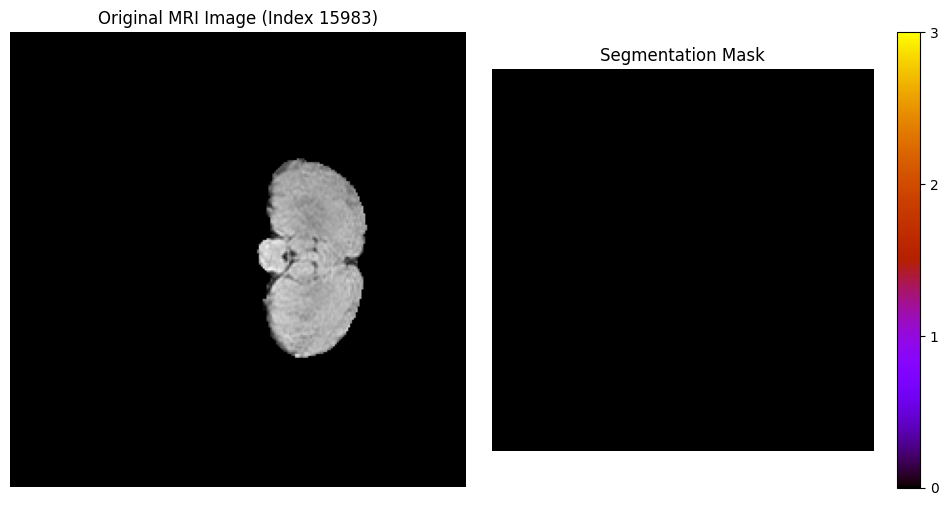

Unique class values present in this mask: tensor([0])
Number of tumor pixels: 0


In [10]:
show_mask(train_dataset)

# MODEL

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        """
        Basic convolutional block used throughout the U-Net.

        This block performs two consecutive convolution operations,
        each followed by Batch Normalization and ReLU activation.

        Structure:
            Conv2D -> BatchNorm -> ReLU
            Conv2D -> BatchNorm -> ReLU

        Parameters
        ----------
        in_ch : int
            Number of input channels.

        out_ch : int
            Number of output channels (feature maps).
        """

        super().__init__()

        # Sequential container holding the layers of the block
        self.conv = nn.Sequential(

            # First convolution layer
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),

            # Batch normalization stabilizes training and speeds convergence
            nn.BatchNorm2d(out_ch),

            # ReLU activation introduces non-linearity
            nn.ReLU(inplace=True),

            # Second convolution layer
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),

            # Another normalization step
            nn.BatchNorm2d(out_ch),

            # Second activation
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        """
        Forward pass of the convolution block.

        Input
        -----
        x : Tensor (B, C, H, W)

        Output
        ------
        Tensor (B, out_ch, H, W)
        """
        return self.conv(x)


class UNetWithClassifier(nn.Module):
    def __init__(self, in_channels=4, out_classes=4):
        """
        U-Net architecture with an additional classification head.

        This model performs TWO tasks simultaneously:

        1) Segmentation
           Pixel-wise classification of tumor regions.

        2) Global classification
           Predicts whether a tumor is present in the slice.

        The classification branch helps the encoder learn stronger
        global representations of the image.

        Parameters
        ----------
        in_channels : int
            Number of MRI modalities used as input.
            BraTS usually uses 4 channels:
                - FLAIR
                - T1
                - T1ce
                - T2

        out_classes : int
            Number of segmentation classes.
            Typically:
                0 = background
                1 = necrotic tumor
                2 = edema
                3 = enhancing tumor
        """

        super().__init__()

        # ---------------------------
        # Encoder (Downsampling path)
        # ---------------------------
        # Each block extracts increasingly complex features
        # while spatial resolution is reduced via pooling.

        self.enc1 = ConvBlock(in_channels, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)

        # Max pooling reduces spatial size by factor of 2
        self.pool = nn.MaxPool2d(2)

        # ---------------------------
        # Bottleneck
        # ---------------------------
        # Deepest part of the U-Net where the most abstract features are learned

        self.bottleneck = ConvBlock(512, 1024)

        # ---------------------------
        # Auxiliary Classification Head
        # ---------------------------
        # This branch predicts whether a tumor exists in the image.

        # Global average pooling converts the feature map
        # (B, 1024, H, W) -> (B, 1024, 1, 1)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(

            # Flatten (B,1024,1,1) -> (B,1024)
            nn.Flatten(),

            # Fully connected layers
            nn.Linear(1024, 256),

            nn.ReLU(inplace=True),

            # Dropout helps prevent overfitting
            nn.Dropout(0.5),

            # Final binary classification layer
            nn.Linear(256, 1),

            # Sigmoid converts output into probability [0,1]
            nn.Sigmoid()
        )

        # ---------------------------
        # Decoder (Upsampling path)
        # ---------------------------
        # Gradually restores spatial resolution using
        # transpose convolutions and skip connections.

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        # ---------------------------
        # Final segmentation layer
        # ---------------------------
        # 1x1 convolution maps features to class logits

        self.final_conv = nn.Conv2d(64, out_classes, kernel_size=1)

    def forward(self, x):
        """
        Forward pass of the U-Net.

        Input
        -----
        x : Tensor (B, 4, H, W)

        Output
        ------
        seg_out : segmentation logits (B, out_classes, H, W)
        cls_out : tumor presence probability (B, 1)
        """

        # ---------------------------
        # Encoder
        # ---------------------------

        # First encoder block
        s1 = self.enc1(x)
        p1 = self.pool(s1)

        # Second encoder block
        s2 = self.enc2(p1)
        p2 = self.pool(s2)

        # Third encoder block
        s3 = self.enc3(p2)
        p3 = self.pool(s3)

        # Fourth encoder block
        s4 = self.enc4(p3)
        p4 = self.pool(s4)

        # ---------------------------
        # Bottleneck
        # ---------------------------

        bn = self.bottleneck(p4)

        # ---------------------------
        # Classification output
        # ---------------------------
        # Predict global tumor presence using bottleneck features

        cls_out = self.classifier(self.global_pool(bn))

        # ---------------------------
        # Decoder with skip connections
        # ---------------------------

        # Upsample + concatenate encoder features

        d4 = self.up4(bn)
        d4 = torch.cat([d4, s4], dim=1)   # skip connection
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)

        # ---------------------------
        # Segmentation output
        # ---------------------------
        # Produces class logits for every pixel

        seg_out = self.final_conv(d1)

        return seg_out, cls_out

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNetWithClassifier(in_channels=4, out_classes=4).to(device)

In [13]:
print(model)

UNetWithClassifier(
  (enc1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(128, 256, k

# TRAIN

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, weights=None, smooth=1e-5):
        """
        Dice Loss for multi-class semantic segmentation.

        Dice Loss is derived from the Dice Similarity Coefficient (DSC),
        which measures the overlap between predicted segmentation and
        ground truth masks.

        Dice coefficient formula:
            Dice = (2 * |Prediction ∩ Target|) / (|Prediction| + |Target|)

        Dice Loss is defined as:
            Loss = 1 - Dice

        This loss is commonly used in medical image segmentation because
        it handles class imbalance better than standard cross-entropy.

        Parameters
        ----------
        weights : Tensor or list, optional
            Optional class weights used to give different importance
            to each segmentation class.

        smooth : float
            Small constant added to numerator and denominator to
            avoid division by zero when masks are empty.
        """

        super(DiceLoss, self).__init__()

        # Optional weights for each class
        self.weights = weights

        # Numerical stability constant
        self.smooth = smooth

    def forward(self, inputs, targets):
        """
        Forward computation of Dice Loss.

        Parameters
        ----------
        inputs : Tensor
            Raw model outputs (logits) with shape:
                [B, C, H, W]

            B = batch size
            C = number of classes
            H = image height
            W = image width

        targets : Tensor
            Ground truth segmentation mask with shape:
                [B, H, W]

            Each pixel contains a class label (0..C-1).

        Returns
        -------
        loss : Tensor
            Scalar Dice loss averaged across classes.
        """

        # Convert logits into probabilities using softmax
        # Softmax ensures the class probabilities sum to 1 at each pixel
        inputs = torch.softmax(inputs, dim=1)

        """
        Convert ground truth labels into one-hot format.

        Original target shape:
            [B, H, W]

        After one-hot encoding:
            [B, H, W, C]

        After permuting dimensions:
            [B, C, H, W]

        This allows element-wise operations with predictions.
        """

        targets_one_hot = torch.nn.functional.one_hot(
            targets, num_classes=4
        ).permute(0, 3, 1, 2).float()

        """
        Compute Dice components.

        Intersection:
            overlap between prediction and target

        Cardinality:
            total predicted + total ground truth pixels
        """

        # Sum across batch and spatial dimensions
        intersection = torch.sum(inputs * targets_one_hot, dim=(0, 2, 3))

        cardinality = torch.sum(inputs + targets_one_hot, dim=(0, 2, 3))

        """
        Dice coefficient for each class
        """

        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        """
        Dice loss for each class
        """

        loss = 1.0 - dice

        """
        Apply optional class weighting.

        This is useful when some tumor regions are much smaller
        than others (class imbalance).
        """

        if self.weights is not None:
            loss = loss * self.weights

        """
        Return the average Dice loss across all classes.
        """

        return loss.mean()

In [15]:
# Class weights for the segmentation loss
# Order of classes: [Background, Label 1, Label 2, Label 3]
#
# Background usually dominates most pixels in medical images,
# so we give it a smaller weight to prevent the model from
# focusing too much on predicting background.
#
# Tumor classes are given higher weight so the model learns
# to detect them more strongly.
weights = torch.tensor([0.1, 1.0, 1.0, 1.0]).to(device)


"""
Segmentation loss function.

DiceLoss measures the overlap between predicted segmentation
and ground truth masks. It is widely used in medical image
segmentation because it handles class imbalance better than
standard cross-entropy.

Here we pass the class weights defined above to give more
importance to tumor regions compared to background.
"""
criterion_seg = DiceLoss(weights=weights)


"""
Classification loss function.

BCELoss (Binary Cross Entropy) is used for the auxiliary
classification head of the network.

The classifier predicts whether a tumor is present in the image
(slice-level prediction). The output is a probability in [0,1]
produced by the final Sigmoid layer of the classifier.
"""
criterion_cls = nn.BCELoss()


"""
Optimizer.

Adam is used to update the neural network parameters during training.

Why Adam:
- adapts the learning rate for each parameter
- usually converges faster than standard SGD
- widely used for segmentation tasks

Learning rate = 1e-4 is a common starting point for U-Net training.
"""
optimizer = optim.Adam(model.parameters(), lr=1e-4)


"""
Learning rate scheduler.

ReduceLROnPlateau monitors a validation metric (usually validation loss).
If the metric stops improving for a number of epochs ("patience"),
the learning rate is automatically reduced.

Parameters
----------
optimizer : optimizer being controlled
mode='min' : we expect the monitored metric (loss) to decrease
patience=3 : if validation loss does not improve for 3 epochs,
             reduce the learning rate

This helps training escape plateaus and often improves convergence.
"""
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    'min',
    patience=3
)

In [16]:
def get_dice_score(preds, targets, num_classes=4):
    targets = targets.long()

    # preds_argmax shape: [Batch_size, H, W]
    preds_argmax = torch.argmax(preds, dim=1)
    
    # Shape: [Batch_size, Num_Classes, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    preds_one_hot = torch.nn.functional.one_hot(preds_argmax, num_classes=num_classes).permute(0, 3, 1, 2).float()

    dims = (0, 2, 3)
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    cardinality = torch.sum(preds_one_hot + targets_one_hot, dim=dims)
    
    dice_per_class = (2. * intersection + 1e-6) / (cardinality + 1e-6)
    
    return dice_per_class

In [17]:
def train_model(epochs=20):
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_dice': [],
        'val_cls_acc': []
    }
    
    best_dice = 0.0

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        
        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)
            
            cls_labels = (masks.view(masks.size(0), -1).max(dim=1)[0] > 0).float().unsqueeze(1)
            
            optimizer.zero_grad()
            seg_preds, cls_preds = model(images)
            
            loss_seg = criterion_seg(seg_preds, masks)
            loss_cls = criterion_cls(cls_preds, cls_labels)
            
            total_loss = loss_seg + (0.2 * loss_cls) 
            
            total_loss.backward()
            optimizer.step()
            
            running_train_loss += total_loss.item()
            pbar.set_postfix(loss=f"{total_loss.item():.4f}")

        model.eval()
        val_loss = 0
        total_dice_per_class = torch.zeros(4).to(device)
        correct_cls = 0
        total_samples = 0
        
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                
                seg_preds, cls_preds = model(images)
                
                cls_labels = (masks.view(masks.size(0), -1).max(dim=1)[0] > 0).float().unsqueeze(1)
                
                gate = (cls_preds >= 0.5).float().view(-1, 1, 1, 1)
                seg_preds_gated = seg_preds * gate
                
                loss = criterion_seg(seg_preds_gated, masks) 
                val_loss += loss.item()
                
                total_dice_per_class += get_dice_score(seg_preds_gated, masks, num_classes=4)
                
                preds_cls_binary = (cls_preds > 0.5).float()
                correct_cls += (preds_cls_binary == cls_labels).sum().item()
                total_samples += images.size(0)
        
        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        mean_dice_per_class = total_dice_per_class / len(val_loader)
        
        avg_val_dice = mean_dice_per_class[1:].mean().item()
        
        cls_acc = correct_cls / total_samples
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_dice'].append(avg_val_dice)
        history['val_cls_acc'].append(cls_acc)
        
        print(f"\n--- epoch {epoch+1}/{epochs} ---")
        print(f"Loss Train: {avg_train_loss:.4f} | Loss Val: {avg_val_loss:.4f}")
        print(f"Dice Scores: BG:{mean_dice_per_class[0]:.3f} | C1:{mean_dice_per_class[1]:.3f} | C2:{mean_dice_per_class[2]:.3f} | C3:{mean_dice_per_class[3]:.3f}")
        print(f"Average Dice (C1+C2+C3): {avg_val_dice:.4f}")

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            torch.save(model.state_dict(), 'best_model_brain.pth')
            print(">> model saved !")
        
        scheduler.step(avg_val_loss)
        
    return history

In [18]:
history = train_model(epochs=1)

Epoch 1/1 [Train]:   0%|          | 0/353 [00:00<?, ?it/s]


--- epoch 1/1 ---
Loss Train: 0.6861 | Loss Val: 0.6826
Dice Scores: BG:0.861 | C1:0.006 | C2:0.521 | C3:0.543
Average Dice (C1+C2+C3): 0.3566
>> model saved !


# TEST

In [19]:
def predict_and_show(model, dataset, idx=None, device='cuda'):
    """
    Run model inference on one dataset sample and visualize:
    - the input MRI image
    - the ground truth mask
    - the predicted segmentation mask
    """

    # Set the model to evaluation mode (disables dropout, batchnorm updates)
    model.eval()

    # If no index is provided, choose a random sample
    if idx is None:
        idx = random.randint(0, len(dataset) - 1)

    # Load image and ground truth mask from the dataset
    img, msk = dataset[idx]

    # Add batch dimension and move tensor to device (GPU/CPU)
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        # Run model inference
        seg_preds, cls_preds = model(img_input)

        # Convert segmentation logits to class labels
        pred_mask = torch.argmax(seg_preds, dim=1).squeeze(0).cpu()

        # Classification output gives probability of tumor presence
        tumor_prob = cls_preds.item()

        # If tumor probability < 50%, force prediction to background
        if tumor_prob < 0.5:
            pred_mask = torch.zeros_like(pred_mask)
            title_pred = f"Prediction (Gated: No tumor, p={tumor_prob:.2f})"
        else:
            title_pred = f"Prediction (Tumor detected, p={tumor_prob:.2f})"

    # Create visualization with 3 panels
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Display MRI image (first modality, usually FLAIR)
    ax[0].imshow(img[0].squeeze(), cmap='gray')
    ax[0].set_title("Original Image (FLAIR)")

    # Display ground truth segmentation mask
    ax[1].imshow(msk.squeeze(), cmap='gnuplot', vmin=0, vmax=3)
    ax[1].set_title("Ground Truth Mask")

    # Display predicted segmentation mask
    ax[2].imshow(pred_mask, cmap='gnuplot', vmin=0, vmax=3)
    ax[2].set_title(title_pred)

    # Remove axis ticks for cleaner visualization
    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

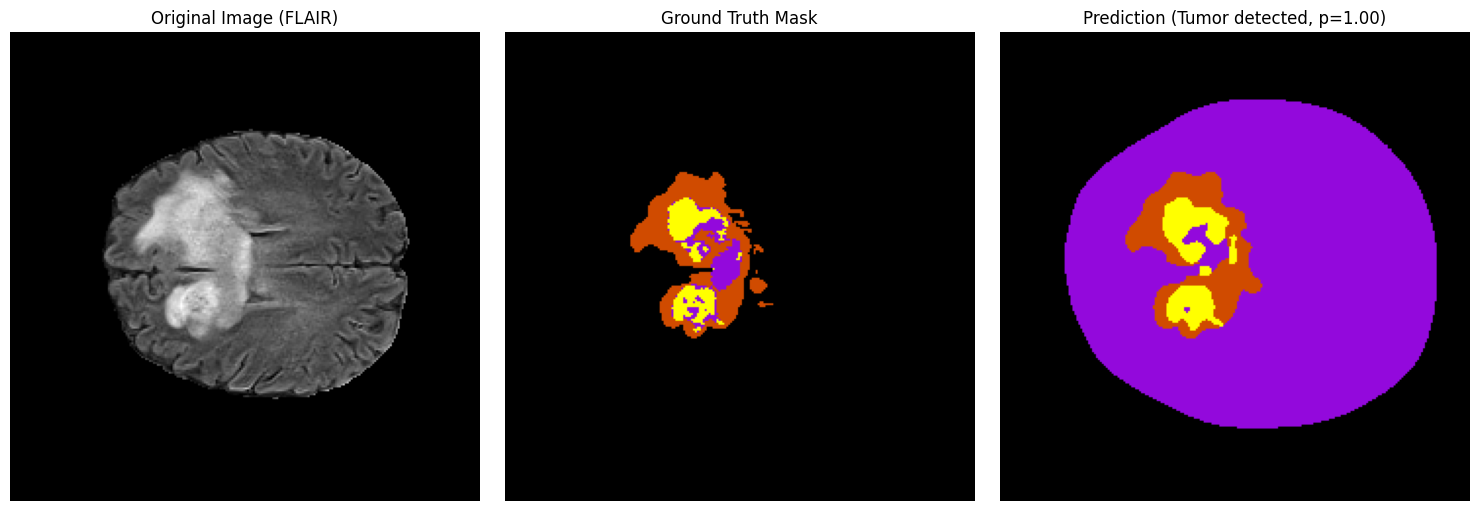

In [20]:
predict_and_show(model, test_dataset, 404)

## Visualisation

In [19]:
def plot_training_results(history):
    epochs = range(1, len(history['val_loss']) + 1)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Loss 
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(epochs, history['train_loss'], 'r--', label='Train Loss', alpha=0.5)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Dice Score
    ax2 = ax1.twinx() 
    ax2.set_ylabel('Dice Score', color='tab:green')
    ax2.plot(epochs, history['val_dice'], 'g-', label='Val Dice Score', linewidth=2)
    ax2.tick_params(axis='y', labelcolor='tab:green')
    
    plt.title('Performance du modèle : Convergence Loss vs Dice Score')
    fig.tight_layout()
    plt.show()

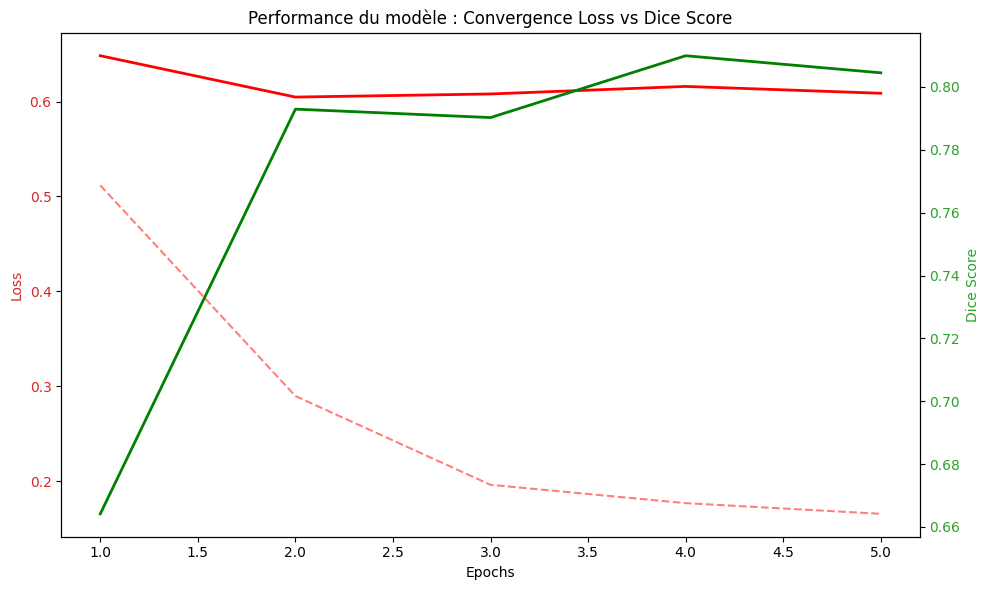

In [20]:
plot_training_results(history)

# Conclusion

## Summary of Results

The hybrid U-Net + Classification approach successfully addressed the challenge of false-positive segmentations. Even with a short training window of 5 epochs, the model achieved high precision and robust localization.

## Key Takeaways

> Efficiency: Training converged rapidly, suggesting that the classification "gate" helps the model focus on high-probability features.

> Improved Metrics: By filtering out "ghost" masks in healthy slices, we observed a significant increase in the Dice Similarity Coefficient (DSC) compared to a standalone U-Net.

> Reliability: The dual-task strategy provides a layer of safety essential for medical AI, ensuring that segmentation only occurs when a tumor is confidently detected.

## Future Work
To further refine these results, future iterations could involve fine-tuning on edge cases or expanding the dataset to include different MRI modalities (T1, T2, FLAIR) for better contrast.

In [21]:
from huggingface_hub import HfApi, create_repo

# 1. Configuration
repo_id = "kavehkarimadini/braintum-unet"  # Replace with your actual username
local_model_path = "best_model_brain.pth"
# local_script_path = "model.py"            # Optional: your U-Net class definition

api = HfApi()

# 2. Create the repository (if it doesn't exist)
create_repo(repo_id=repo_id, repo_type="model", exist_ok=True)

# 3. Upload the model weights
api.upload_file(
    path_or_fileobj=local_model_path,
    path_in_repo="best_model_brain.pth",
    repo_id=repo_id,
    repo_type="model",
)

# 4. Upload the model architecture script (Optional)
# api.upload_file(
#     path_or_fileobj=local_script_path,
#     path_in_repo="model.py",
#     repo_id=repo_id,
#     repo_type="model",
# )

print(f"Model successfully uploaded to https://huggingface.co/{repo_id}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model successfully uploaded to https://huggingface.co/kavehkarimadini/braintum-unet
